In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

In [2]:
df=pd.read_csv(r"C:\Users\asala\Downloads\world_happiness_2023.csv")

In [3]:
df.columns

Index(['Country name', 'Regional indicator', 'Ladder score',
       'Logged GDP per capita', 'Social support', 'Healthy life expectancy',
       'Freedom to make life choices', 'Generosity',
       'Perceptions of corruption'],
      dtype='object')

In [4]:
df.columns=['Country','Region','Happiness_Score','GDP','Social_support','Life_Expecctancy','Freedom','Generosity','Corruption']

In [5]:
print(f"{len(df)}countries loaded")

63countries loaded


In [6]:
print(df.head())

       Country                        Region  Happiness_Score     GDP  \
0      Finland                Western Europe            7.804  10.775   
1      Denmark                Western Europe            7.586  10.933   
2      Iceland                Western Europe            7.525  10.878   
3       Israel  Middle East and North Africa            7.473  10.527   
4  Netherlands                Western Europe            7.464  11.015   

   Social_support  Life_Expecctancy  Freedom  Generosity  Corruption  
0           0.954              71.9    0.949       0.142       0.179  
1           0.954              72.7    0.931       0.168       0.234  
2           0.983              72.5    0.961       0.260       0.150  
3           0.916              72.4    0.903       0.149       0.826  
4           0.939              72.4    0.879       0.240       0.296  


In [7]:
print("No.of regions in dataset:")
print(df['Region'].value_counts())
print("\nScore range:",df['Happiness_Score'].min(),"-",df['Happiness_Score'].max())
print("\nBottom 10 countries:")
print(df.nsmallest(10, 'Happiness_Score')[['Country','Region','Happiness_Score']])

No.of regions in dataset:
Region
Western Europe                  15
Latin America and Caribbean     13
Central and Eastern Europe       7
Sub-Saharan Africa               7
Middle East and North Africa     6
North America and ANZ            4
Southeast Asia                   4
South Asia                       4
East Asia                        3
Name: count, dtype: int64

Score range: 1.859 - 7.804

Bottom 10 countries:
        Country                        Region  Happiness_Score
60  Afghanistan                    South Asia            1.859
61      Lebanon  Middle East and North Africa            2.392
62     Zimbabwe            Sub-Saharan Africa            2.995
52     Ethiopia            Sub-Saharan Africa            3.564
53     Tanzania            Sub-Saharan Africa            3.698
48   Bangladesh                    South Asia            3.892
47        India                    South Asia            4.036
50        Kenya            Sub-Saharan Africa            4.112
54       

## Task-1 Regional Comparision chart

In [8]:
# Step-1
region_avg=(df.groupby('Region')['Happiness_Score']
    .mean()
    .reset_index()
    .sort_values('Happiness_Score'))
print(region_avg)

                         Region  Happiness_Score
5                    South Asia         3.618250
7            Sub-Saharan Africa         4.064714
3  Middle East and North Africa         4.943333
6                Southeast Asia         5.695250
2   Latin America and Caribbean         5.699000
1                     East Asia         5.966000
0    Central and Eastern Europe         6.338143
4         North America and ANZ         7.018250
8                Western Europe         7.085533


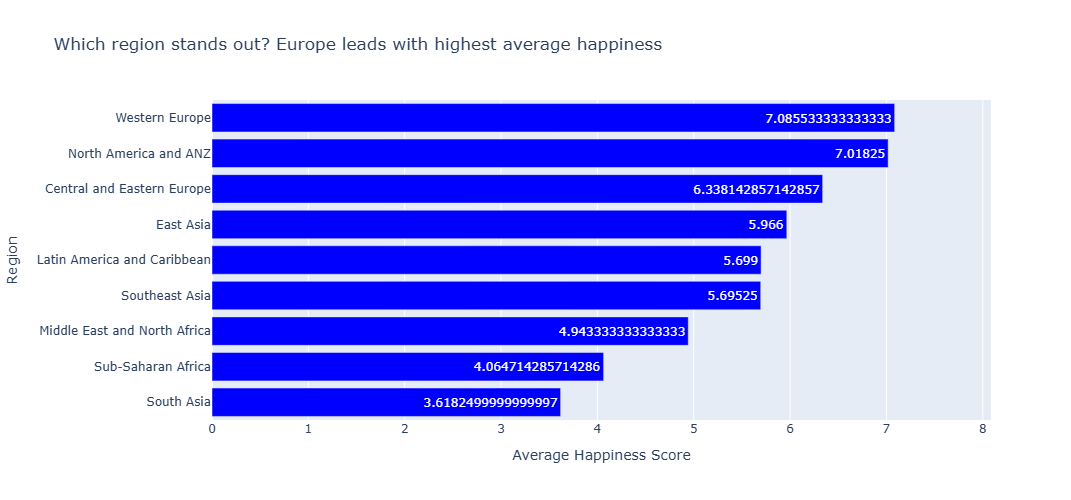

In [41]:
# Creating horizontal bar chart
fig =px.bar(
    region_avg,
    x='Happiness_Score',
    y='Region',
    orientation='h',
    text='Happiness_Score',
    title='Which region stands out? Europe leads with highest average happiness'
)

fig.update_layout(
    xaxis_title='Average Happiness Score',
    yaxis_title='Region',
    height=500,
    xaxis=dict(range=[0, region_avg['Happiness_Score'].max() + 1]) 
)

fig.update_traces(marker_color='Blue')

fig.show()

## Task-2 Bottom vs Top: A Contrast Story

In [34]:
# step-1:Get top and Bottom countries

top8 = df.nlargest(8, 'Happiness_Score').copy()
top8['Group'] = 'Top 8'
bottom8 = df.nsmallest(8, 'Happiness_Score').copy()
bottom8['Group'] = 'Bottom 8'

combined = pd.concat([bottom8, top8]).sort_values('Happiness_Score')
global_avg = df['Happiness_Score'].mean()
print(f"Global average: {global_avg:.2f}")

Global average: 5.81


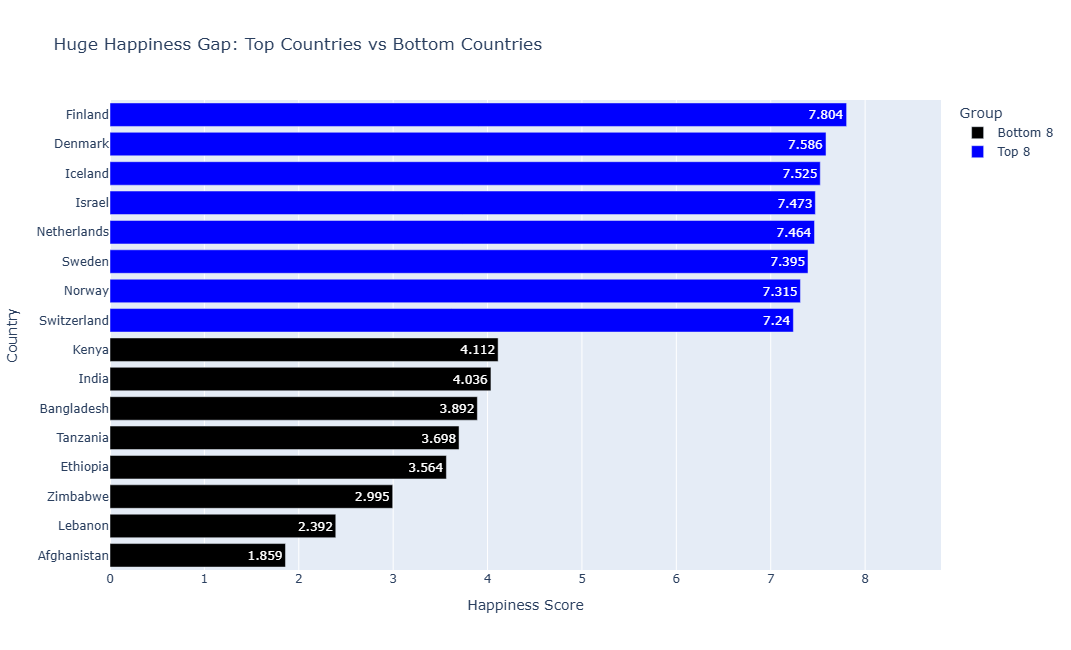

In [39]:
fig = px.bar(
    combined,
    x='Happiness_Score',
    y='Country',
    color='Group',
    orientation='h',
    text='Happiness_Score',
    height=650,
    title='Huge Happiness Gap: Top Countries vs Bottom Countries',
    color_discrete_map={
        'Top 8': 'blue',
        'Bottom 8': 'black'
    }
)

fig.update_layout(
    xaxis_title='Happiness Score',
    yaxis_title='Country',
    xaxis=dict(range=[0, combined['Happiness_Score'].max() + 1])
)

fig.show()